# Indian Startup Funding Analysis (2020-2025)
**Dataset:** indian_startup_funding_2020_2025_sample.csv (1,100 deals)  
**Tools:** Pandas, SQLite, Matplotlib, Seaborn  
**Goal:** Funding trends, sector rotation, geographic patterns, and 2026-2028 projections

In [4]:
# Install dependencies (run once)
!pip install pandas numpy matplotlib seaborn openpyxl

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PALETTE = ['#4e9af1', '#f1a94e', '#50c878', '#e05c5c', '#b07cff',
           '#f06292', '#4dd0e1', '#fff176', '#a5d6a7', '#ef9a9a',
           '#80cbc4', '#ce93d8']

print('Imports done')

Imports done


---
## Section 1 - Load & Clean Data

In [3]:
# Load the dataset
raw = pd.read_csv('../data/2020-2025/indian_startup_funding_2020_2025_sample.csv')
print(f'Loaded: {raw.shape[0]} rows, {raw.shape[1]} columns')
print(f'Columns: {raw.columns.tolist()}')
raw.head()

Loaded: 1100 rows, 8 columns
Columns: ['Startup', 'Industry', 'SubVertical', 'City', 'Investors', 'InvestmentType', 'InvestmentAmount_USD', 'Date']


,Startup,Industry,SubVertical,City,Investors,InvestmentType,InvestmentAmount_USD,Date
0,Housejoy,EdTech,K12,Mumbai,Lightspeed India,Seed,199000,19-04-2023
1,Groww,Media,Streaming,Bengaluru,IFC,Seed,1668000,28-01-2025
2,Groww,Mobility,Ride Sharing,Hyderabad,"Nexus Venture Partners, Peak XV",Series B,38052000,14-03-2021
3,FarmBox,Consumer Electronics,Wearables,Gurugram,"Kalaari Capital, Y Combinator",Seed,455000,11-09-2023
4,Udaan,RealEstate,Rental Tech,Mumbai,Bessemer Venture Partners,Seed,89000,31-01-2024


In [4]:
df = raw.copy()

# Rename columns to something consistent
df = df.rename(columns={
    'Startup': 'startup_name',
    'Industry': 'sector',
    'SubVertical': 'sub_vertical',
    'City': 'city',
    'Investors': 'investor',
    'InvestmentType': 'round_type',
    'InvestmentAmount_USD': 'funding_usd',
    'Date': 'deal_date',
})

# Parse dates (DD-MM-YYYY format)
df['deal_date'] = pd.to_datetime(df['deal_date'], format='%d-%m-%Y', errors='coerce')
df['deal_year']  = df['deal_date'].dt.year
df['deal_month'] = df['deal_date'].dt.month

# Fill blanks
df['sector']     = df['sector'].fillna('Unclassified').str.strip()
df['city']       = df['city'].fillna('Unknown').str.strip()
df['round_type'] = df['round_type'].fillna('Undisclosed').str.strip()
df['investor']   = df['investor'].fillna('Unknown').str.strip()

# Sector bucketing
SECTOR_MAP = {
    r'fin.*tech|fintech|payment|lending|insurance|neobank|wealthtech': 'Fintech',
    r'ed.*tech|edtech|e-learning|learning|education': 'Edtech',
    r'health.*tech|healthtech|medtech|pharma|biotech|clinical|hospital|wellness': 'Healthtech',
    r'e-?comm|ecommerce|retail|d2c|direct.*consumer|fashion|beauty': 'Ecommerce/D2C',
    r'saas|enterprise|b2b.*software|cloud|crm|erp|hr.?tech|workflow': 'SaaS/Enterprise',
    r'\bai\b|\bml\b|artificial|machine learning|nlp|generative|llm|data science': 'AI/ML',
    r'deep.*tech|deeptech|space|robotics|semiconductor|drone|quantum': 'Deeptech',
    r'\bev\b|electric vehicle|cleantech|climate|renewable|solar|green|energy|mobility': 'EV/Cleantech',
    r'agri|agriculture|farm|agtech': 'Agritech',
    r'logistics|supply chain|freight|delivery|last.mile': 'Logistics',
    r'food.*tech|foodtech|restaurant|cloud kitchen|beverage': 'Foodtech',
    r'real.*estate|proptech|construction': 'Proptech',
}

def map_sector(s):
    s_lower = str(s).lower()
    for pattern, label in SECTOR_MAP.items():
        if pd.notna(s) and re.search(pattern, s_lower):
            return label
    return 'Other'

df['sector_clean'] = df['sector'].apply(map_sector)

# Round type bucketing
ROUND_MAP = {
    r'pre.?seed|pre.?series.?a|angel': 'Seed/Angel',
    r'^seed': 'Seed/Angel',
    r'series a': 'Series A',
    r'series b': 'Series B',
    r'series c': 'Series C',
    r'series [d-z]|late.?stage|growth|private equity': 'Late Stage',
    r'ipo|public': 'IPO',
    r'grant|government': 'Grant',
    r'debt|venture debt': 'Debt',
}

def map_round(r):
    r_lower = str(r).lower()
    for pattern, label in ROUND_MAP.items():
        if re.search(pattern, r_lower):
            return label
    return 'Undisclosed'

df['round_clean'] = df['round_type'].apply(map_round)

# City bucketing
CITY_MAP = {
    r'bengaluru|bangalore': 'Bengaluru',
    r'mumbai|bombay': 'Mumbai',
    r'delhi|ncr|gurugram|gurgaon|noida|new delhi|faridabad|ghaziabad': 'Delhi/NCR',
    r'hyderabad': 'Hyderabad',
    r'chennai|madras': 'Chennai',
    r'pune': 'Pune',
    r'ahmedabad': 'Ahmedabad',
    r'kolkata|calcutta': 'Kolkata',
}

def map_city(c):
    c_lower = str(c).lower()
    for pattern, label in CITY_MAP.items():
        if re.search(pattern, c_lower):
            return label
    return 'Other'

df['city_clean'] = df['city'].apply(map_city)

# Dedup
before = len(df)
df = df.drop_duplicates(subset=['startup_name', 'deal_date', 'funding_usd'])
print(f'Dedup: {before} -> {len(df)} rows')

# Quick sanity check
print(f'Year range: {df["deal_year"].min()} - {df["deal_year"].max()}')
print(f'Funding range: ${df["funding_usd"].min():,.0f} - ${df["funding_usd"].max():,.0f}')
df.head()

Dedup: 1100 -> 1100 rows
Year range: 2020 - 2025
Funding range: $5,000 - $574,676,000


,startup_name,sector,sub_vertical,city,investor,round_type,funding_usd,deal_date,deal_year,deal_month,sector_clean,round_clean,city_clean
0,Housejoy,EdTech,K12,Mumbai,Lightspeed India,Seed,199000,2023-04-19,2023,4,Edtech,Seed/Angel,Mumbai
1,Groww,Media,Streaming,Bengaluru,IFC,Seed,1668000,2025-01-28,2025,1,Other,Seed/Angel,Bengaluru
2,Groww,Mobility,Ride Sharing,Hyderabad,"Nexus Venture Partners, Peak XV",Series B,38052000,2021-03-14,2021,3,EV/Cleantech,Series B,Hyderabad
3,FarmBox,Consumer Electronics,Wearables,Gurugram,"Kalaari Capital, Y Combinator",Seed,455000,2023-09-11,2023,9,Other,Seed/Angel,Delhi/NCR
4,Udaan,RealEstate,Rental Tech,Mumbai,Bessemer Venture Partners,Seed,89000,2024-01-31,2024,1,Proptech,Seed/Angel,Mumbai


In [5]:
# Load into SQLite for analytical queries
conn = sqlite3.connect(':memory:')
df.to_sql('deals', conn, if_exists='replace', index=False)
print(f'SQLite table ready: {len(df)} rows')

def sql(query, label=''):
    result = pd.read_sql_query(query, conn)
    # Auto-convert numeric-looking columns
    for col in result.columns:
        try:
            result[col] = pd.to_numeric(result[col])
        except (ValueError, TypeError):
            pass
    if label:
        print(f'\n-- {label} --')
        print(result.to_string(index=False))
    return result

SQLite table ready: 1100 rows


---
## Section 1b — 3-Layer Sector Reclassification
**Corrects mislabelled sectors** using:
1. **Layer 1** — Known company name lookup (150+ Indian startups)
2. **Layer 2** — Regex pattern matching (12 sector patterns)
3. **Layer 3** — Investor-based sector inference (30+ specialist investors)

> This replaces the simple `sector_clean` column with a more accurate `sector_final`.

In [6]:
# Import the 3-layer reclassification system
import sys; sys.path.insert(0, '../scripts')
from sector_reclassifier import (
    reclassify_sector, apply_reclassification,
    plot_reclassification_impact,
    KNOWN_COMPANIES, SECTOR_PATTERNS, INVESTOR_SECTOR_MAP
)

print(f'Reclassifier loaded:')
print(f'  Layer 1: {len(KNOWN_COMPANIES)} known companies')
print(f'  Layer 2: {len(SECTOR_PATTERNS)} sector regex patterns')
print(f'  Layer 3: {len(INVESTOR_SECTOR_MAP)} investor mappings')

Reclassifier loaded:
  Layer 1: 309 known companies
  Layer 2: 12 sector regex patterns
  Layer 3: 35 investor mappings


In [7]:
# Apply the 3-layer reclassification to the cleaned dataframe
df = apply_reclassification(df)

# Replace sector_clean with the new sector_final for all downstream analysis
df['sector_clean_old'] = df['sector_clean'].copy()  # Keep original for comparison
df['sector_clean'] = df['sector_final']  # Override for downstream cells

# Update the SQLite table too
df.to_sql('deals', conn, if_exists='replace', index=False)
print(f'\n✅ SQLite table updated with reclassified sectors: {len(df)} rows')

🔄 Applying 3-layer sector reclassification...
   Dataset: 1100 rows

  📊 RECLASSIFICATION VALIDATION REPORT

1️⃣  RECLASSIFICATION COVERAGE BY LAYER:
---------------------------------------------
  🏷️ name_lookup       349  ( 31.7%)  ███████████████
  🔍 regex             655  ( 59.5%)  █████████████████████████████
  💰 investor           21  (  1.9%)  
  ❓ fallback           75  (  6.8%)  ███
  ────────────────────────────────────────
  TOTAL              1100

2️⃣  CONFIDENCE DISTRIBUTION:
---------------------------------------------
  🟢 high       349  ( 31.7%)
  🟡 medium     655  ( 59.5%)
  🔴 low         96  (  8.7%)

3️⃣  SPOT-CHECK (20 random samples):
-----------------------------------------------------------------------------------------------
  Startup              Original           Final              Layer         Conf     Status
  ──────────────────── ────────────────── ────────────────── ───────────── ──────── ──────────
  AeroAnalytics        FoodTech           Foodtech 

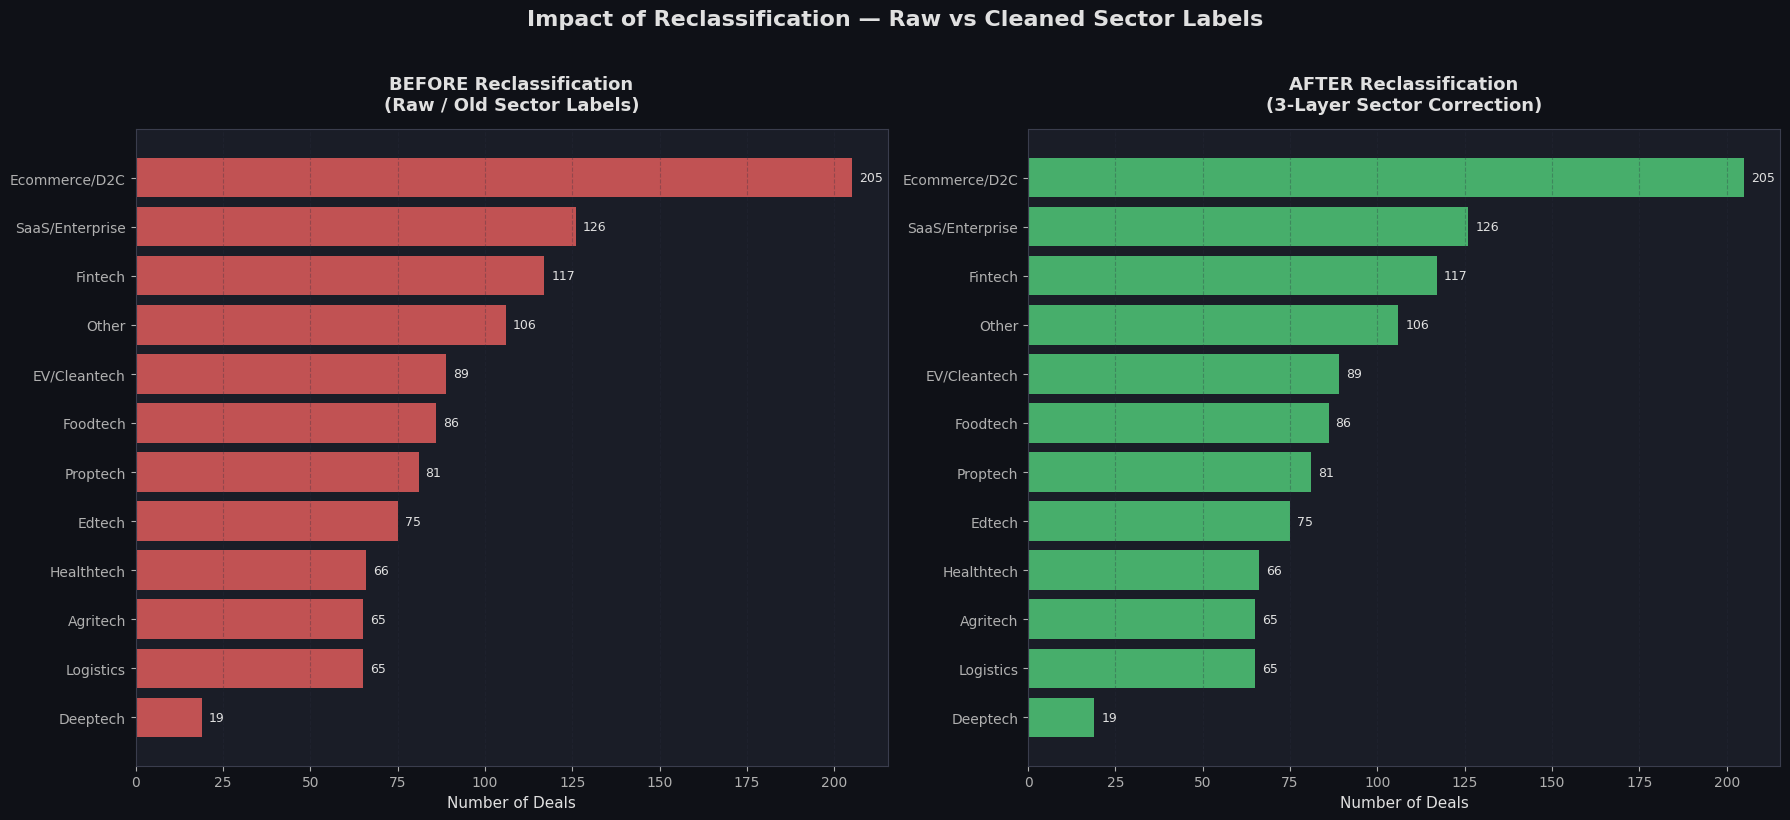

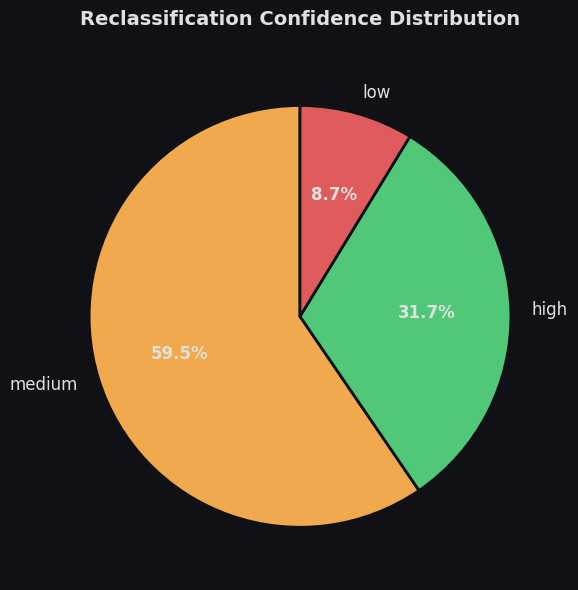

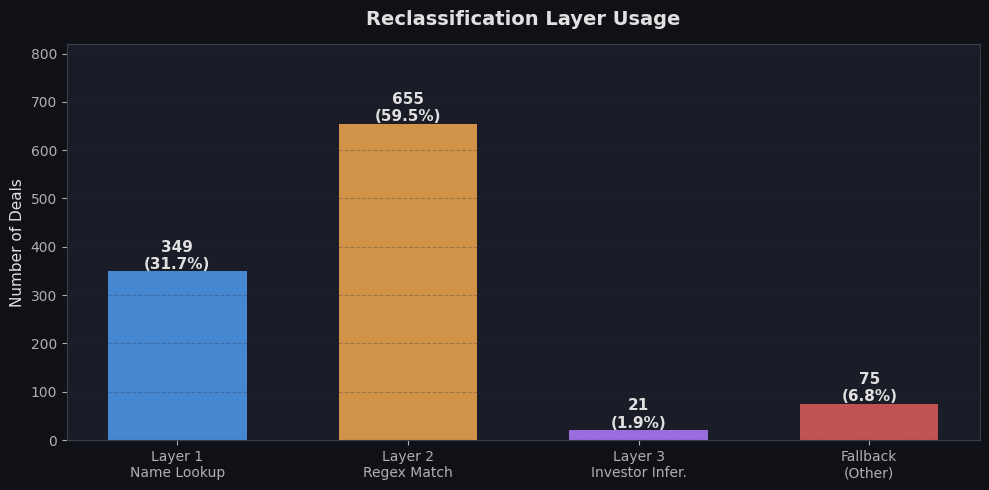

In [8]:
# Generate reclassification impact visualizations
plot_reclassification_impact(df)

---
## Section 2 - Data Quality Check

In [9]:
# Null audit
sql("""
    SELECT
        COUNT(*)                            AS total_rows,
        COUNT(*) - COUNT(startup_name)       AS nulls_name,
        COUNT(*) - COUNT(sector_clean)       AS nulls_sector,
        COUNT(*) - COUNT(city_clean)         AS nulls_city,
        COUNT(*) - COUNT(round_clean)        AS nulls_round,
        COUNT(*) - COUNT(funding_usd)        AS nulls_funding,
        COUNT(*) - COUNT(deal_year)          AS nulls_year
    FROM deals
""", label='NULL AUDIT')


-- NULL AUDIT --
 total_rows  nulls_name  nulls_sector  nulls_city  nulls_round  nulls_funding  nulls_year
       1100           0             0           0            0              0           0


,total_rows,nulls_name,nulls_sector,nulls_city,nulls_round,nulls_funding,nulls_year
0,1100,0,0,0,0,0,0


In [10]:
# Yearly summary
sql("""
    SELECT
        deal_year,
        COUNT(*)                        AS deals,
        ROUND(SUM(funding_usd)/1e9, 2)  AS total_bn,
        ROUND(AVG(funding_usd)/1e6, 2)  AS avg_mn,
        COUNT(DISTINCT sector_clean)    AS sectors,
        COUNT(DISTINCT city_clean)      AS cities
    FROM deals
    GROUP BY deal_year
    ORDER BY deal_year
""", label='YEARLY OVERVIEW')


-- YEARLY OVERVIEW --
 deal_year  deals  total_bn  avg_mn  sectors  cities
      2020    195      4.76   24.39       12       8
      2021    183      6.02   32.92       12       8
      2022    200      4.51   22.55       12       8
      2023    213      4.00   18.79       12       8
      2024    225      5.98   26.58       12       8
      2025     84      2.81   33.49       11       8


,deal_year,deals,total_bn,avg_mn,sectors,cities
0,2020,195,4.76,24.39,12,8
1,2021,183,6.02,32.92,12,8
2,2022,200,4.51,22.55,12,8
3,2023,213,4.00,18.79,12,8
4,2024,225,5.98,26.58,12,8
5,2025,84,2.81,33.49,11,8


---
## Section 3 - Analytical Queries (8 Insights)

In [11]:
# Insight 1: YoY Funding Trend
yoy = sql("""
    WITH yearly AS (
        SELECT
            deal_year,
            COUNT(*)                       AS deal_count,
            ROUND(SUM(funding_usd)/1e9, 3) AS total_bn
        FROM deals
        GROUP BY deal_year
    )
    SELECT
        deal_year,
        deal_count,
        total_bn,
        LAG(total_bn) OVER (ORDER BY deal_year) AS prev_bn,
        ROUND(
            (total_bn - LAG(total_bn) OVER (ORDER BY deal_year))
            / LAG(total_bn) OVER (ORDER BY deal_year) * 100, 1
        ) AS yoy_pct
    FROM yearly
    ORDER BY deal_year
""", label='YoY Funding Trend')


-- YoY Funding Trend --
 deal_year  deal_count  total_bn  prev_bn  yoy_pct
      2020         195     4.757      NaN      NaN
      2021         183     6.025    4.757     26.7
      2022         200     4.510    6.025    -25.1
      2023         213     4.002    4.510    -11.3
      2024         225     5.980    4.002     49.4
      2025          84     2.813    5.980    -53.0


In [12]:
# Insight 2: Sector Share by Year
sector_year = sql("""
    WITH sy AS (
        SELECT
            deal_year,
            sector_clean,
            COUNT(*)                       AS deal_count,
            ROUND(SUM(funding_usd)/1e9, 3) AS funding_bn
        FROM deals
        GROUP BY deal_year, sector_clean
    ),
    totals AS (
        SELECT deal_year, SUM(funding_bn) AS year_total
        FROM sy GROUP BY deal_year
    )
    SELECT
        sy.deal_year,
        sy.sector_clean,
        sy.deal_count,
        sy.funding_bn,
        ROUND(sy.funding_bn / t.year_total * 100, 1) AS pct_of_year
    FROM sy
    JOIN totals t ON sy.deal_year = t.deal_year
    ORDER BY sy.deal_year, sy.funding_bn DESC
""", label='Sector Share by Year')


-- Sector Share by Year --
 deal_year    sector_clean  deal_count  funding_bn  pct_of_year
      2020    EV/Cleantech          13       1.028         21.6
      2020   Ecommerce/D2C          28       1.006         21.1
      2020           Other          24       0.584         12.3
      2020        Agritech          12       0.513         10.8
      2020        Proptech          12       0.449          9.4
      2020          Edtech          15       0.388          8.2
      2020      Healthtech          12       0.192          4.0
      2020         Fintech          26       0.179          3.8
      2020        Deeptech           6       0.153          3.2
      2020 SaaS/Enterprise          24       0.125          2.6
      2020        Foodtech          12       0.109          2.3
      2020       Logistics          11       0.031          0.7
      2021   Ecommerce/D2C          38       1.526         25.3
      2021        Foodtech          14       1.127         18.7
      2021  

In [13]:
# Insight 3: Funding Stage Distribution
stages = sql("""
    SELECT
        deal_year,
        round_clean,
        COUNT(*)                       AS deal_count,
        ROUND(SUM(funding_usd)/1e9, 3) AS total_bn,
        ROUND(AVG(funding_usd)/1e6, 2) AS avg_mn
    FROM deals
    WHERE round_clean != 'Undisclosed'
    GROUP BY deal_year, round_clean
    ORDER BY deal_year, total_bn DESC
""", label='Stage Distribution')


-- Stage Distribution --
 deal_year round_clean  deal_count  total_bn  avg_mn
      2020  Late Stage           8     2.511  313.86
      2020    Series C          14     1.466  104.70
      2020    Series B          20     0.518   25.89
      2020    Series A          41     0.188    4.58
      2020  Seed/Angel         107     0.045    0.42
      2020        Debt           3     0.027    9.15
      2021  Late Stage          12     3.278  273.14
      2021    Series C          19     1.887   99.32
      2021    Series B          19     0.640   33.70
      2021    Series A          34     0.160    4.71
      2021  Seed/Angel          89     0.029    0.33
      2021        Debt           3     0.028    9.31
      2022  Late Stage           8     2.098  262.25
      2022    Series C          17     1.391   81.83
      2022    Series B          19     0.661   34.77
      2022    Series A          46     0.258    5.61
      2022        Debt           5     0.061   12.24
      2022  Seed/Ang

In [14]:
# Insight 4: City-wise Funding
cities = sql("""
    SELECT
        deal_year,
        city_clean,
        COUNT(*)                       AS deal_count,
        ROUND(SUM(funding_usd)/1e9, 3) AS total_bn
    FROM deals
    WHERE city_clean != 'Other'
    GROUP BY deal_year, city_clean
    ORDER BY deal_year, total_bn DESC
""", label='City Funding')


-- City Funding --
 deal_year city_clean  deal_count  total_bn
      2020       Pune          20     1.120
      2020  Delhi/NCR          67     1.057
      2020    Chennai          19     0.793
      2020  Ahmedabad          23     0.740
      2020    Kolkata          20     0.677
      2020  Hyderabad          18     0.244
      2020     Mumbai          14     0.105
      2020  Bengaluru          14     0.021
      2021  Delhi/NCR          53     1.733
      2021  Ahmedabad          11     0.936
      2021       Pune          18     0.901
      2021  Bengaluru          24     0.709
      2021  Hyderabad          17     0.616
      2021    Kolkata          27     0.601
      2021    Chennai          18     0.335
      2021     Mumbai          15     0.194
      2022  Delhi/NCR          66     1.235
      2022    Kolkata          16     1.075
      2022  Bengaluru          19     0.560
      2022     Mumbai          23     0.556
      2022  Hyderabad          19     0.378
      2022  

In [15]:
# Insight 5: Top 15 Investors
# Split comma-separated investors first
inv_df = df[['startup_name', 'deal_year', 'funding_usd', 'investor']].copy()
inv_df = inv_df[inv_df['investor'] != 'Unknown']
inv_df['investor'] = inv_df['investor'].str.split(',')
inv_df = inv_df.explode('investor')
inv_df['investor'] = inv_df['investor'].str.strip()
inv_df = inv_df[inv_df['investor'].str.len() > 2]
inv_df.to_sql('inv_deals', conn, if_exists='replace', index=False)

top_investors = sql("""
    SELECT
        investor,
        COUNT(DISTINCT startup_name) AS startups_backed,
        COUNT(*)                     AS total_deals,
        ROUND(SUM(funding_usd)/1e6, 1) AS total_mn
    FROM inv_deals
    GROUP BY investor
    ORDER BY total_deals DESC
    LIMIT 15
""", label='Top 15 Investors')


-- Top 15 Investors --
               investor  startups_backed  total_deals  total_mn
           Y Combinator               61           84    1958.8
            Mirae Asset               56           83    1657.4
              Info Edge               65           82    2014.4
                  Accel               65           80    2058.0
                    IFC               61           78    1395.9
  Sequoia Capital India               62           77    1988.4
        Kalaari Capital               62           77    2758.1
        Prosus Ventures               55           75    1959.2
Tiger Global Management               62           74    1334.6
         Ribbit Capital               60           73    1805.3
 Nexus Venture Partners               57           73    1603.9
         Zodius Capital               57           72    2438.7
        Kedaara Capital               54           70    1630.1
                Peak XV               52           69    1865.1
   SoftBank Visi

In [16]:
# Insight 6: Deal Size by Sector
deal_size = sql("""
    SELECT
        sector_clean,
        COUNT(*)                       AS deals,
        ROUND(MIN(funding_usd)/1e6, 2) AS min_mn,
        ROUND(AVG(funding_usd)/1e6, 2) AS avg_mn,
        ROUND(MAX(funding_usd)/1e6, 2) AS max_mn,
        ROUND(SUM(funding_usd)/1e9, 2) AS total_bn
    FROM deals
    WHERE sector_clean != 'Other'
    GROUP BY sector_clean
    ORDER BY avg_mn DESC
""", label='Deal Size by Sector')


-- Deal Size by Sector --
   sector_clean  deals  min_mn  avg_mn  max_mn  total_bn
       Foodtech     86    0.01   49.90  489.94      4.29
         Edtech     75    0.01   30.34  574.68      2.28
   EV/Cleantech     89    0.01   27.59  556.75      2.46
       Deeptech     19    0.02   26.12  182.99      0.50
  Ecommerce/D2C    205    0.01   25.03  458.29      5.13
        Fintech    117    0.01   23.63  566.55      2.76
SaaS/Enterprise    126    0.01   22.51  491.72      2.84
      Logistics     65    0.01   21.26  384.55      1.38
       Proptech     81    0.01   20.16  396.77      1.63
       Agritech     65    0.01   15.34  482.36      1.00
     Healthtech     66    0.03   13.21  230.42      0.87


In [17]:
# Insight 7: Sector x Stage Matrix
matrix = sql("""
    SELECT
        sector_clean,
        round_clean,
        COUNT(*) AS deals
    FROM deals
    WHERE round_clean NOT IN ('Undisclosed', 'IPO', 'Grant', 'Debt')
      AND sector_clean NOT IN ('Other', 'Unclassified')
    GROUP BY sector_clean, round_clean
    ORDER BY sector_clean, deals DESC
""", label='Sector x Stage Matrix')


-- Sector x Stage Matrix --
   sector_clean round_clean  deals
       Agritech  Seed/Angel     38
       Agritech    Series A     14
       Agritech    Series B      6
       Agritech  Late Stage      2
       Agritech    Series C      1
       Deeptech  Seed/Angel     10
       Deeptech    Series C      3
       Deeptech    Series A      3
       Deeptech    Series B      2
   EV/Cleantech  Seed/Angel     38
   EV/Cleantech    Series A     25
   EV/Cleantech    Series C      8
   EV/Cleantech    Series B      7
   EV/Cleantech  Late Stage      5
  Ecommerce/D2C  Seed/Angel    102
  Ecommerce/D2C    Series A     46
  Ecommerce/D2C    Series C     20
  Ecommerce/D2C    Series B     16
  Ecommerce/D2C  Late Stage     11
         Edtech  Seed/Angel     42
         Edtech    Series C     11
         Edtech    Series A      9
         Edtech    Series B      7
         Edtech  Late Stage      2
        Fintech  Seed/Angel     64
        Fintech    Series A     18
        Fintech    Series 

In [18]:
# Insight 8: Seasonality
seasonality = sql("""
    SELECT
        deal_month,
        COUNT(*)                       AS deal_count,
        ROUND(SUM(funding_usd)/1e9, 3) AS total_bn,
        ROUND(AVG(funding_usd)/1e6, 2) AS avg_mn
    FROM deals
    WHERE deal_month IS NOT NULL
    GROUP BY deal_month
    ORDER BY deal_month
""", label='Seasonality')


-- Seasonality --
 deal_month  deal_count  total_bn  avg_mn
          1          99     2.562   25.88
          2          90     3.413   37.92
          3         104     2.552   24.54
          4         100     2.967   29.67
          5         105     2.981   28.39
          6         104     1.656   15.92
          7          93     1.292   13.89
          8          92     2.195   23.86
          9          75     2.543   33.91
         10          81     2.478   30.60
         11          77     1.874   24.34
         12          80     1.573   19.67


---
## Section 4 - Visualisations

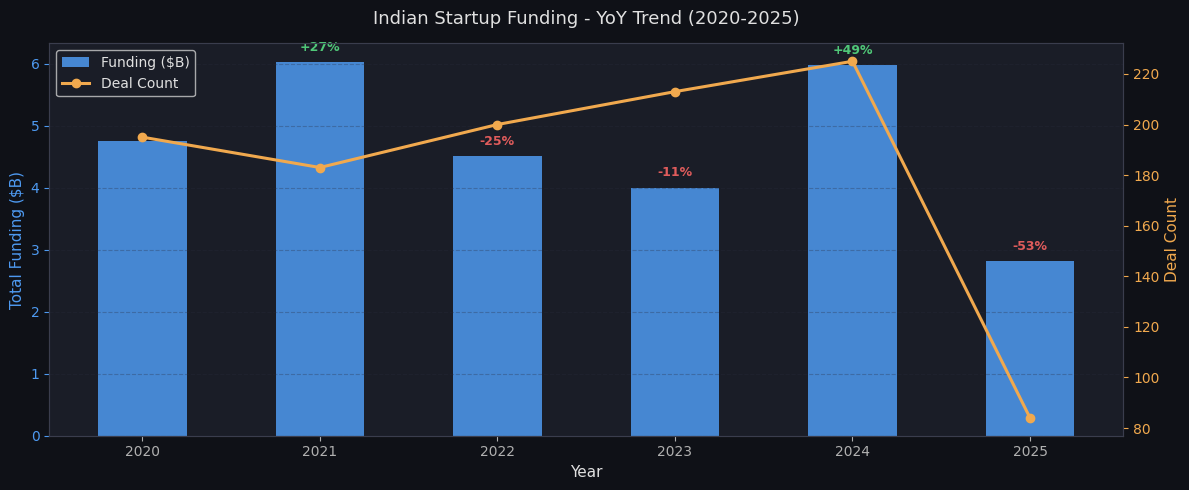

In [19]:
# Chart 1: YoY Funding (bar + line)
fig, ax1 = plt.subplots(figsize=(12, 5))

plot = yoy.dropna(subset=['total_bn'])
ax1.bar(plot['deal_year'], plot['total_bn'],
        color=PALETTE[0], alpha=0.85, width=0.5, label='Funding ($B)')
ax1.set_ylabel('Total Funding ($B)', color=PALETTE[0])
ax1.tick_params(axis='y', colors=PALETTE[0])

ax2 = ax1.twinx()
ax2.plot(plot['deal_year'], plot['deal_count'],
         color=PALETTE[1], marker='o', linewidth=2.2, label='Deal Count')
ax2.set_ylabel('Deal Count', color=PALETTE[1])
ax2.tick_params(axis='y', colors=PALETTE[1])
ax2.set_facecolor('#1a1d27')

for _, row in plot.dropna(subset=['yoy_pct']).iterrows():
    clr = '#50c878' if row['yoy_pct'] >= 0 else '#e05c5c'
    ax1.annotate(f"{row['yoy_pct']:+.0f}%",
                 xy=(row['deal_year'], row['total_bn']),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=9, color=clr, fontweight='bold')

ax1.set_title('Indian Startup Funding - YoY Trend (2020-2025)', fontsize=13, pad=14)
ax1.set_xlabel('Year')
ax1.grid(axis='y', alpha=0.3)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left', facecolor='#1a1d27')
plt.tight_layout()
plt.savefig('../visualizations/viz1_yoy_trend.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

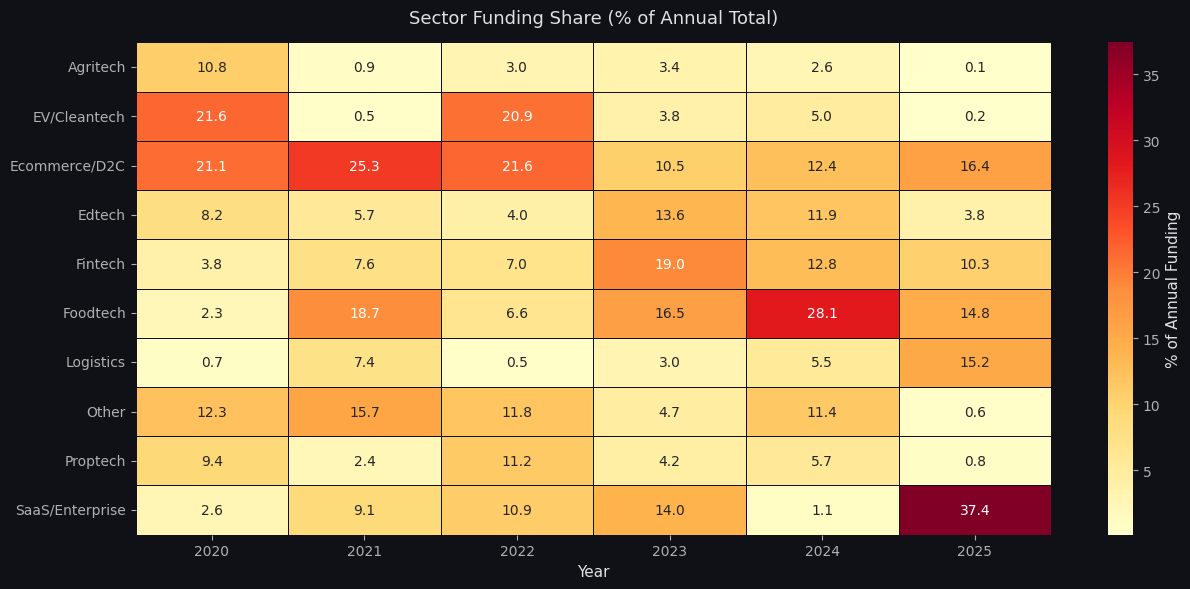

In [20]:
# Chart 2: Sector Heatmap (% share of annual funding)
pivot = sector_year.pivot_table(
    index='sector_clean', columns='deal_year',
    values='pct_of_year', aggfunc='sum'
).fillna(0)

top10 = sector_year.groupby('sector_clean')['funding_bn'].sum().nlargest(10).index
pivot = pivot.loc[pivot.index.isin(top10)]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, linecolor='#0f1117',
            ax=ax, cbar_kws={'label': '% of Annual Funding'})
ax.set_title('Sector Funding Share (% of Annual Total)', fontsize=13, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visualizations/viz2_sector_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

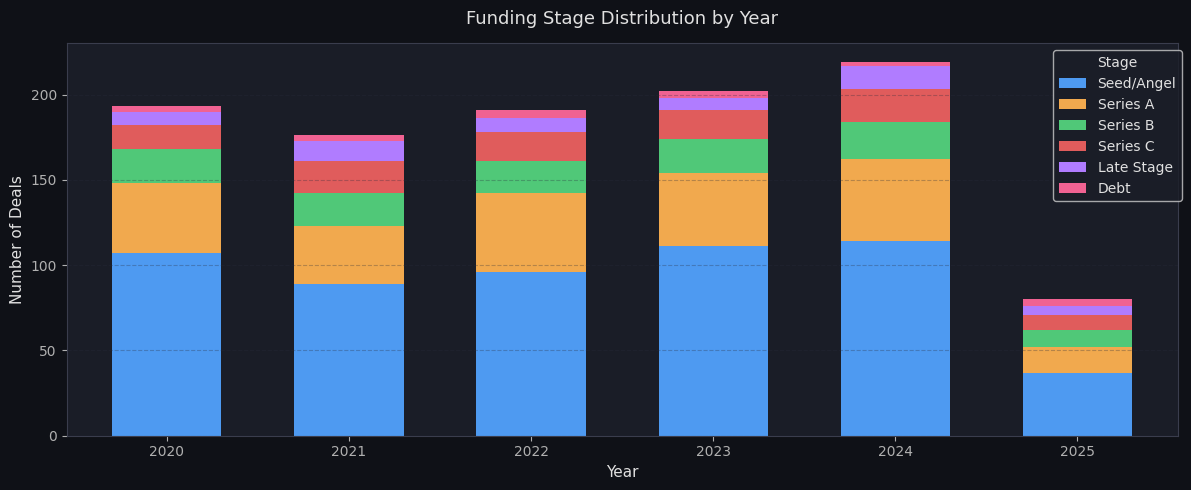

In [21]:
# Chart 3: Funding Stage (stacked bar)
stage_pivot = stages.pivot_table(
    index='deal_year', columns='round_clean',
    values='deal_count', aggfunc='sum'
).fillna(0)

order = ['Seed/Angel', 'Series A', 'Series B', 'Series C', 'Late Stage', 'Debt']
stage_pivot = stage_pivot[[c for c in order if c in stage_pivot.columns]]

fig, ax = plt.subplots(figsize=(12, 5))
stage_pivot.plot(kind='bar', stacked=True, ax=ax,
                 color=PALETTE[:len(stage_pivot.columns)],
                 width=0.6, edgecolor='none')
ax.set_title('Funding Stage Distribution by Year', fontsize=13, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Deals')
ax.legend(title='Stage', bbox_to_anchor=(1.01, 1), facecolor='#1a1d27')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/viz3_stage_mix.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

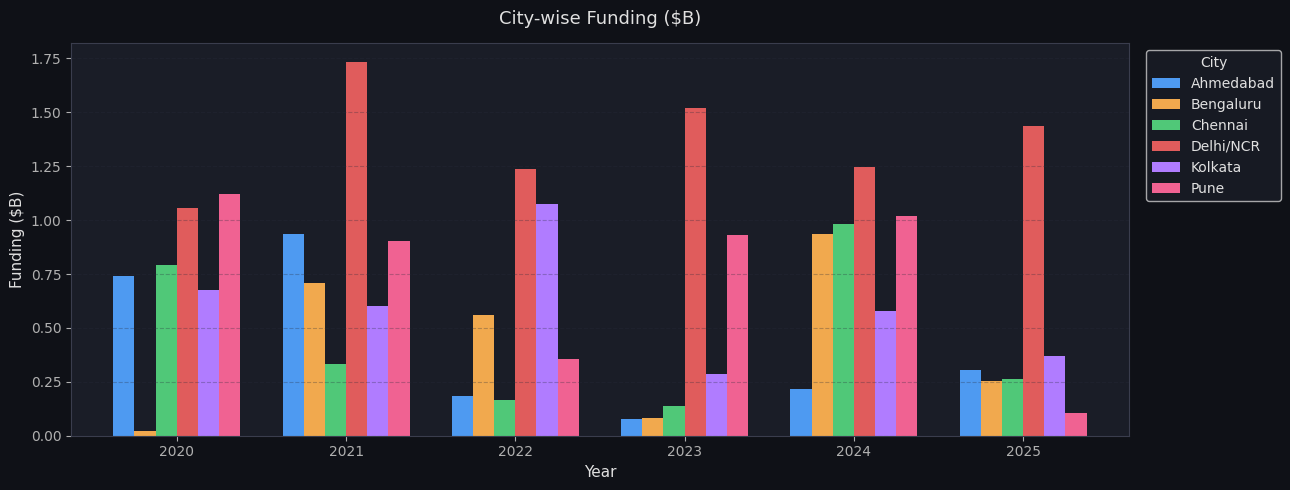

In [22]:
# Chart 4: City Funding (grouped bar)
city_pivot = cities.pivot_table(
    index='city_clean', columns='deal_year',
    values='total_bn', aggfunc='sum'
).fillna(0)

top6 = cities.groupby('city_clean')['total_bn'].sum().nlargest(6).index
city_pivot = city_pivot.loc[city_pivot.index.isin(top6)]

fig, ax = plt.subplots(figsize=(13, 5))
city_pivot.T.plot(kind='bar', ax=ax,
                  color=PALETTE[:len(city_pivot)],
                  width=0.75, edgecolor='none')
ax.set_title('City-wise Funding ($B)', fontsize=13, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Funding ($B)')
ax.legend(title='City', bbox_to_anchor=(1.01, 1), facecolor='#1a1d27')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/viz4_city_funding.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

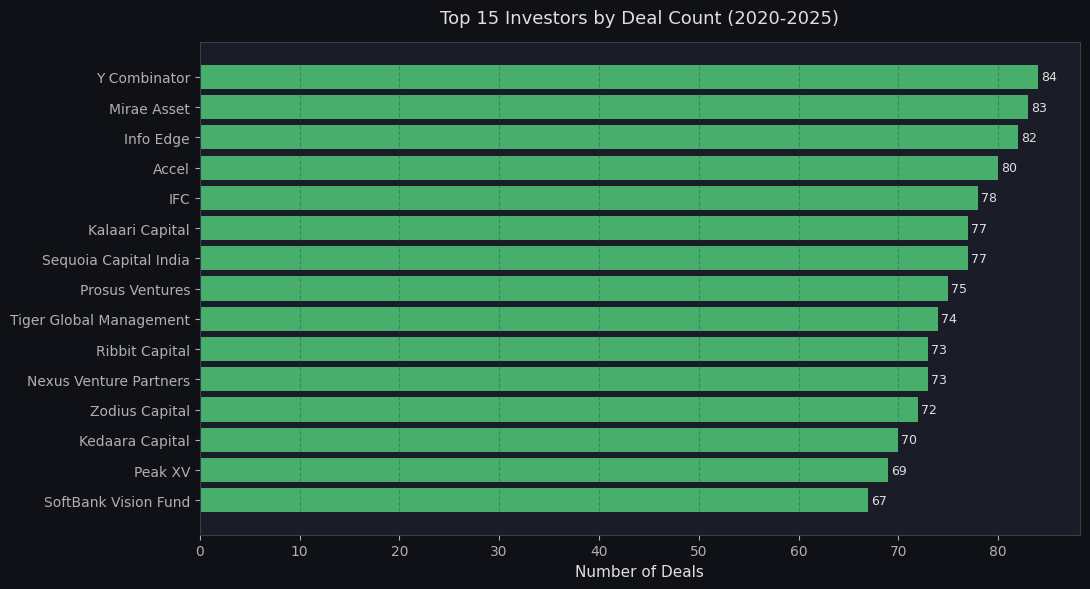

In [23]:
# Chart 5: Top 15 Investors
fig, ax = plt.subplots(figsize=(11, 6))
ti = top_investors.sort_values('total_deals')
bars = ax.barh(ti['investor'], ti['total_deals'],
               color=PALETTE[2], alpha=0.85, edgecolor='none')

for bar, val in zip(bars, ti['total_deals']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)

ax.set_title('Top 15 Investors by Deal Count (2020-2025)', fontsize=13, pad=14)
ax.set_xlabel('Number of Deals')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/viz5_top_investors.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

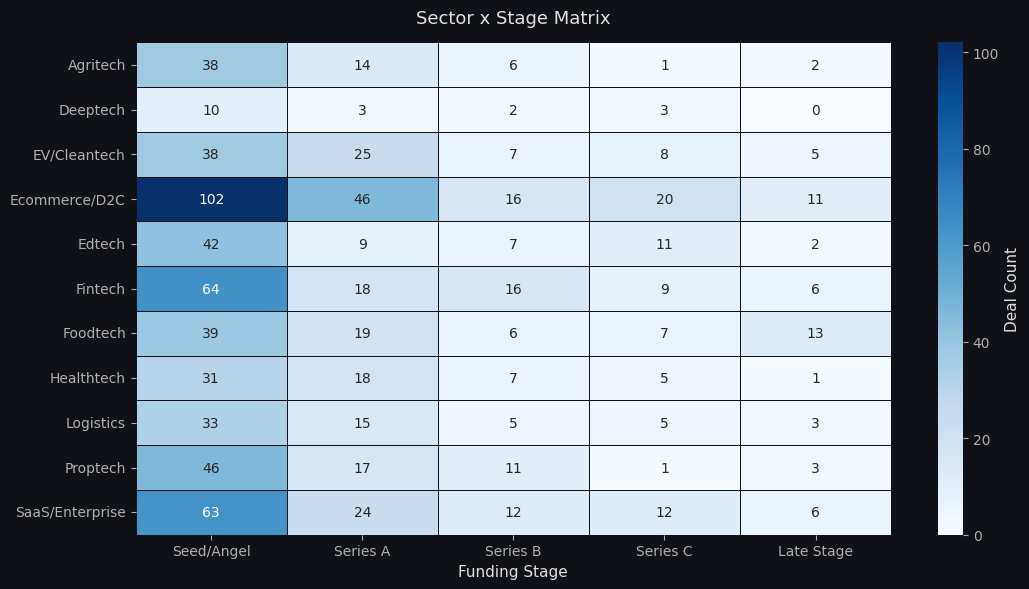

In [24]:
# Chart 6: Sector x Stage Matrix
mat_pivot = matrix.pivot_table(
    index='sector_clean', columns='round_clean',
    values='deals', aggfunc='sum'
).fillna(0)

col_order = [c for c in ['Seed/Angel', 'Series A', 'Series B', 'Series C', 'Late Stage']
             if c in mat_pivot.columns]
mat_pivot = mat_pivot[col_order]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(mat_pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, linecolor='#0f1117', ax=ax,
            cbar_kws={'label': 'Deal Count'})
ax.set_title('Sector x Stage Matrix', fontsize=13, pad=14)
ax.set_xlabel('Funding Stage')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visualizations/viz6_sector_stage.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

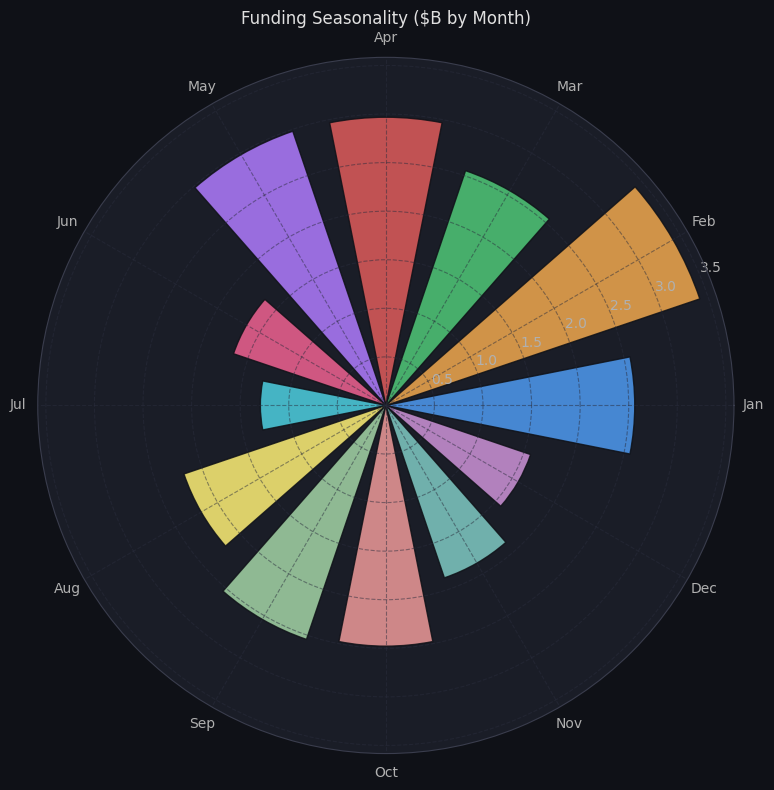

In [25]:
# Chart 7: Seasonality (polar chart)
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seas = seasonality.set_index('deal_month').reindex(range(1,13)).fillna(0)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
radii = seas['total_bn'].values
width = 2*np.pi / 12 * 0.75

ax.bar(theta, radii, width=width, bottom=0,
       color=PALETTE[:12], alpha=0.85, edgecolor='#0f1117')
ax.set_xticks(theta)
ax.set_xticklabels(MONTHS, fontsize=10)
ax.set_facecolor('#1a1d27')
ax.set_title('Funding Seasonality ($B by Month)', fontsize=12, pad=24, color='#e0e0e0')
ax.tick_params(colors='#b0b0b0')
ax.grid(color='#2a2d3d')
plt.tight_layout()
plt.savefig('../visualizations/viz7_seasonality.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## Section 5 - Projections (2026-2028)

Projected Funding ($B):
  2026: $3.64B
  2027: $3.35B
  2028: $3.05B


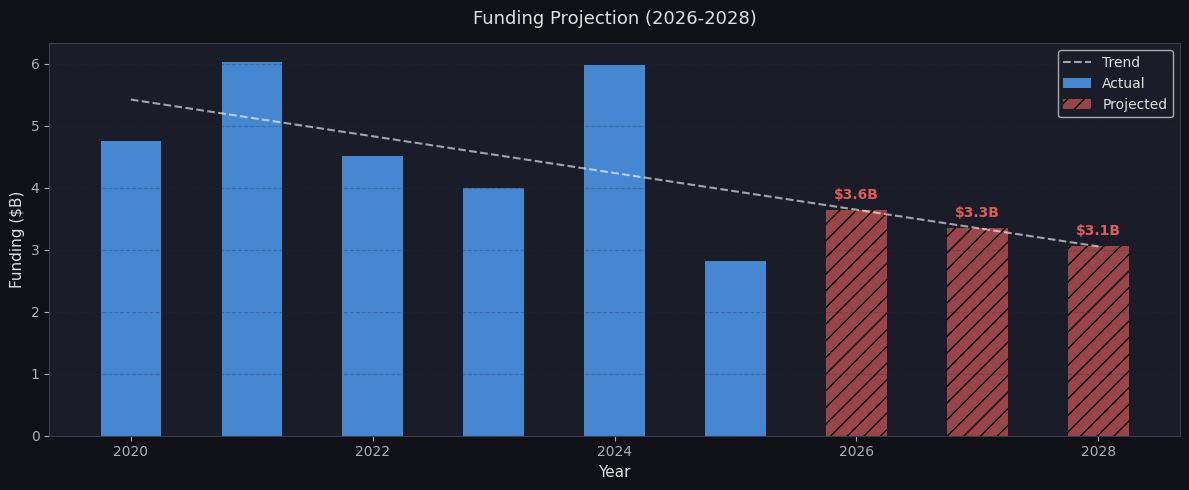

In [26]:
# Linear regression on yearly funding
hist = yoy.dropna(subset=['total_bn'])
x = hist['deal_year'].values
y = hist['total_bn'].values

coefs = np.polyfit(x, y, 1)
future = np.array([2026, 2027, 2028])
predicted = np.polyval(coefs, future)

print('Projected Funding ($B):')
for yr, val in zip(future, predicted):
    print(f'  {yr}: ${val:.2f}B')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, y, color=PALETTE[0], alpha=0.85, width=0.5, label='Actual')
ax.bar(future, predicted, color=PALETTE[3], alpha=0.65, width=0.5,
       label='Projected', hatch='//')
ax.plot(np.append(x, future), np.polyval(coefs, np.append(x, future)),
        color='white', linestyle='--', linewidth=1.5, alpha=0.6, label='Trend')

for yr, val in zip(future, predicted):
    ax.annotate(f'${val:.1f}B', xy=(yr, val), xytext=(0, 8),
                textcoords='offset points', ha='center',
                fontsize=10, color=PALETTE[3], fontweight='bold')

ax.set_title('Funding Projection (2026-2028)', fontsize=13, pad=14)
ax.set_ylabel('Funding ($B)')
ax.set_xlabel('Year')
ax.legend(facecolor='#1a1d27')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/viz8_projection.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

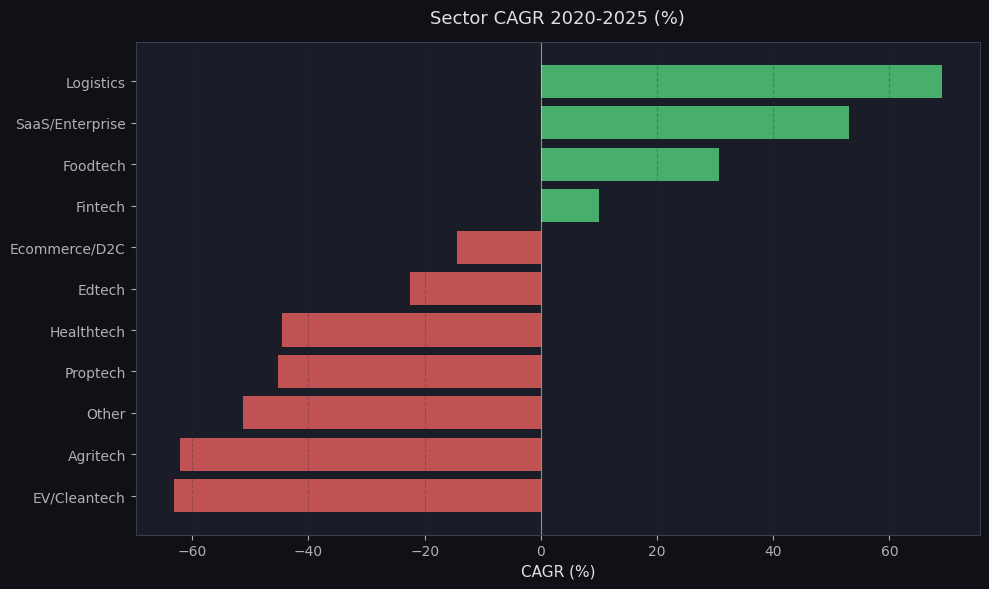

In [27]:
# Sector CAGR (earliest year vs latest year in data)
years_available = sorted(sector_year['deal_year'].unique())
yr_start, yr_end = years_available[0], years_available[-1]
n_years = yr_end - yr_start

cagr_data = sector_year[sector_year['deal_year'].isin([yr_start, yr_end])].copy()
cagr_pivot = cagr_data.pivot_table(
    index='sector_clean', columns='deal_year',
    values='funding_bn', aggfunc='sum'
).dropna()

if yr_start in cagr_pivot.columns and yr_end in cagr_pivot.columns:
    cagr_pivot = cagr_pivot[cagr_pivot[yr_start] > 0]
    cagr_pivot['cagr_pct'] = (
        (cagr_pivot[yr_end] / cagr_pivot[yr_start]) ** (1/n_years) - 1
    ) * 100
    cagr_pivot = cagr_pivot.sort_values('cagr_pct', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#50c878' if v >= 0 else '#e05c5c' for v in cagr_pivot['cagr_pct']]
    ax.barh(cagr_pivot.index, cagr_pivot['cagr_pct'], color=colors, alpha=0.85)
    ax.axvline(0, color='white', linewidth=0.8, alpha=0.5)
    ax.set_title(f'Sector CAGR {yr_start}-{yr_end} (%)', fontsize=13, pad=14)
    ax.set_xlabel('CAGR (%)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../visualizations/viz9_sector_cagr.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
    plt.show()
else:
    print(f'Need data for both {yr_start} and {yr_end}')

---
## Section 6 - Summary

In [28]:
total_deals   = len(df)
total_funding = df['funding_usd'].sum() / 1e9
top_sector    = df.groupby('sector_clean')['funding_usd'].sum().idxmax()
top_city      = df.groupby('city_clean')['funding_usd'].sum().idxmax()
peak_year     = int(yoy.loc[yoy['total_bn'].idxmax(), 'deal_year'])

print('=' * 50)
print('  KEY FINDINGS')
print('=' * 50)
print(f'  Total deals    : {total_deals:,}')
print(f'  Total funding  : ${total_funding:.1f}B')
print(f'  Peak year      : {peak_year}')
print(f'  Top sector     : {top_sector}')
print(f'  Top city       : {top_city}')
print('=' * 50)

  KEY FINDINGS
  Total deals    : 1,100
  Total funding  : $28.1B
  Peak year      : 2021
  Top sector     : Ecommerce/D2C
  Top city       : Delhi/NCR


In [29]:
# Export cleaned data
df.to_csv('../outputs/cleaned_startup_data.csv', index=False)
print('Saved cleaned_startup_data.csv')

Saved cleaned_startup_data.csv
